# TPC-DS Benchmark Results Analysis
**Fabric Lakehouse SQL Endpoint vs Fabric Warehouse**

This notebook loads benchmark results from `results/` and produces:
- Summary statistics (median, p90, p95) per endpoint, query and scale factor
- Cold vs. warm cache comparison
- Lakehouse table configuration comparison (default / partitioned / zorder / vorder)
- Bar charts and box plots of query latency

In [9]:
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

## 1. Load results

In [10]:
RESULTS_DIR = '../results'

csv_files = sorted(glob.glob(os.path.join(RESULTS_DIR, 'benchmark_*.csv')))
print(f'Found {len(csv_files)} result file(s):')
for f in csv_files:
    print(' ', f)

df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
df['timestamp'] = pd.to_datetime(df['timestamp'])
print(f'\nTotal rows: {len(df):,}')
df.head()

Found 1 result file(s):
  ../results\benchmark_20260410T160604.csv

Total rows: 80


,run_id,timestamp,endpoint,scale_factor,query_id,cache_mode,repetition,elapsed_ms,rows_returned,status,error_message
0,c9541237-a5de-422b-891e-0ed91e488b64,2026-04-10 15:59:16.325933+00:00,lakehouse_default,SF100,q01,cold,1,7706.55,960,success,NaN
1,a76caf26-2912-4730-8fa0-0befa5a91e9a,2026-04-10 15:59:22.571630+00:00,lakehouse_default,SF100,q02,cold,1,5045.15,100,success,NaN
2,42cc6be9-a42f-4081-a8dc-14bab842b9a8,2026-04-10 15:59:25.379060+00:00,lakehouse_default,SF100,q03,cold,1,1510.88,10,success,NaN
3,1e28db67-3d26-47aa-8cd4-ad1814c97d1d,2026-04-10 15:59:32.273857+00:00,lakehouse_default,SF100,q04,cold,1,5805.39,0,success,NaN
4,25435308-5b00-483c-8163-cfeb691b13ce,2026-04-10 15:59:43.815684+00:00,lakehouse_default,SF100,q05,cold,1,10539.70,200,success,NaN


## 2. Data quality check

In [11]:
print('Status breakdown:')
print(df['status'].value_counts())
print()

# Filter to successful runs only
df_ok = df[df['status'] == 'success'].copy()
print(f'Successful runs: {len(df_ok):,} / {len(df):,}')
print()
print('Endpoints present:', df_ok['endpoint'].unique().tolist())
print('Scale factors:',     df_ok['scale_factor'].unique().tolist())
print('Queries:',           df_ok['query_id'].unique().tolist())

Status breakdown:
status
success    80
Name: count, dtype: int64

Successful runs: 80 / 80

Endpoints present: ['lakehouse_default', 'lakehouse_partitioned', 'lakehouse_vorder', 'warehouse']
Scale factors: ['SF100']
Queries: ['q01', 'q02', 'q03', 'q04', 'q05']


## 3. Summary statistics (median / p90 / p95)

In [12]:
def pct(p):
    return lambda x: x.quantile(p / 100)

summary = (
    df_ok
    .groupby(['scale_factor', 'endpoint', 'query_id', 'cache_mode'])['elapsed_ms']
    .agg(
        median=pct(50),
        p90=pct(90),
        p95=pct(95),
        mean='mean',
        count='count'
    )
    .reset_index()
    .sort_values(['scale_factor', 'cache_mode', 'query_id', 'median'])
)
summary

,scale_factor,endpoint,query_id,cache_mode,median,p90,p95,mean,count
10,SF100,lakehouse_partitioned,q01,cold,1799.18,1799.180,1799.180,1799.180000,1
30,SF100,warehouse,q01,cold,4154.28,4154.280,4154.280,4154.280000,1
20,SF100,lakehouse_vorder,q01,cold,4262.62,4262.620,4262.620,4262.620000,1
0,SF100,lakehouse_default,q01,cold,7706.55,7706.550,7706.550,7706.550000,1
12,SF100,lakehouse_partitioned,q02,cold,3546.49,3546.490,3546.490,3546.490000,1
32,SF100,warehouse,q02,cold,4368.60,4368.600,4368.600,4368.600000,1
2,SF100,lakehouse_default,q02,cold,5045.15,5045.150,5045.150,5045.150000,1
22,SF100,lakehouse_vorder,q02,cold,5288.06,5288.060,5288.060,5288.060000,1
14,SF100,lakehouse_partitioned,q03,cold,1059.06,1059.060,1059.060,1059.060000,1
4,SF100,lakehouse_default,q03,cold,1510.88,1510.880,1510.880,1510.880000,1


## 4. Cold vs. warm — median latency per query

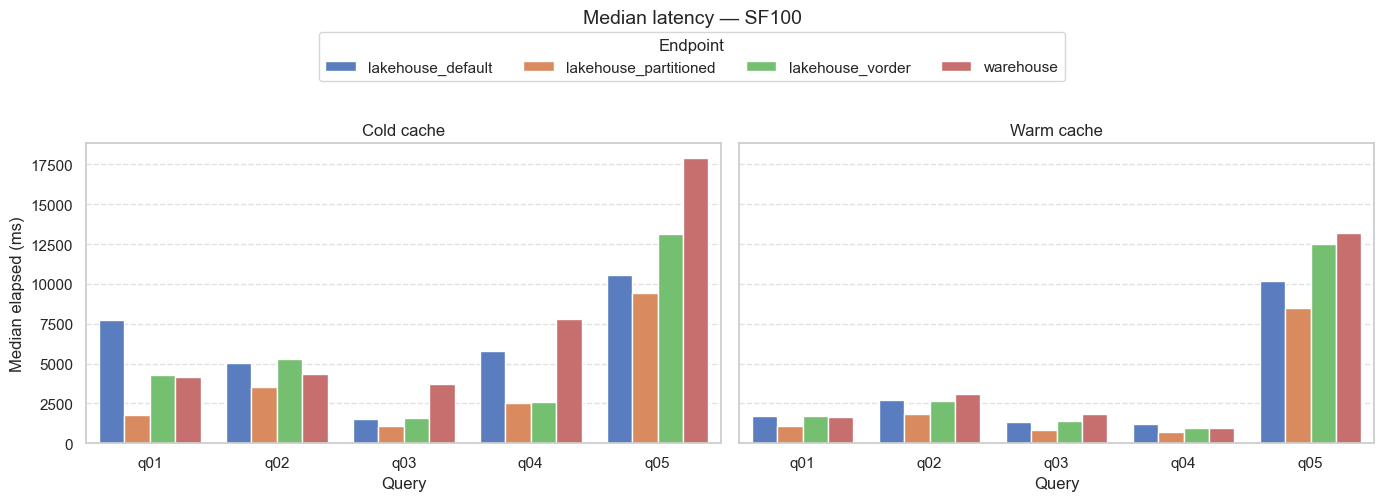

In [13]:
ENDPOINT_ORDER = ['lakehouse_default', 'lakehouse_partitioned', 'lakehouse_vorder', 'warehouse']

for sf in sorted(df_ok['scale_factor'].unique()):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    fig.suptitle(f'Median latency — {sf}', fontsize=14, y=1.0)

    for ax, cache_mode in zip(axes, ['cold', 'warm']):
        data = summary[
            (summary['scale_factor'] == sf) &
            (summary['cache_mode'] == cache_mode)
        ]
        sns.barplot(
            data=data, x='query_id', y='median',
            hue='endpoint', hue_order=ENDPOINT_ORDER, ax=ax
        )
        ax.set_title(f'{cache_mode.capitalize()} cache')
        ax.set_xlabel('Query')
        ax.set_ylabel('Median elapsed (ms)' if cache_mode == 'cold' else '')
        ax.yaxis.grid(True, linestyle='--', alpha=0.6)
        ax.set_axisbelow(True)
        ax.get_legend().remove()

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        title='Endpoint',
        loc='upper center',
        bbox_to_anchor=(0.5, 0.97),
        ncol=len(ENDPOINT_ORDER),
        frameon=True,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.88])
    plt.show()

## 5. Lakehouse config comparison (warm, all queries)

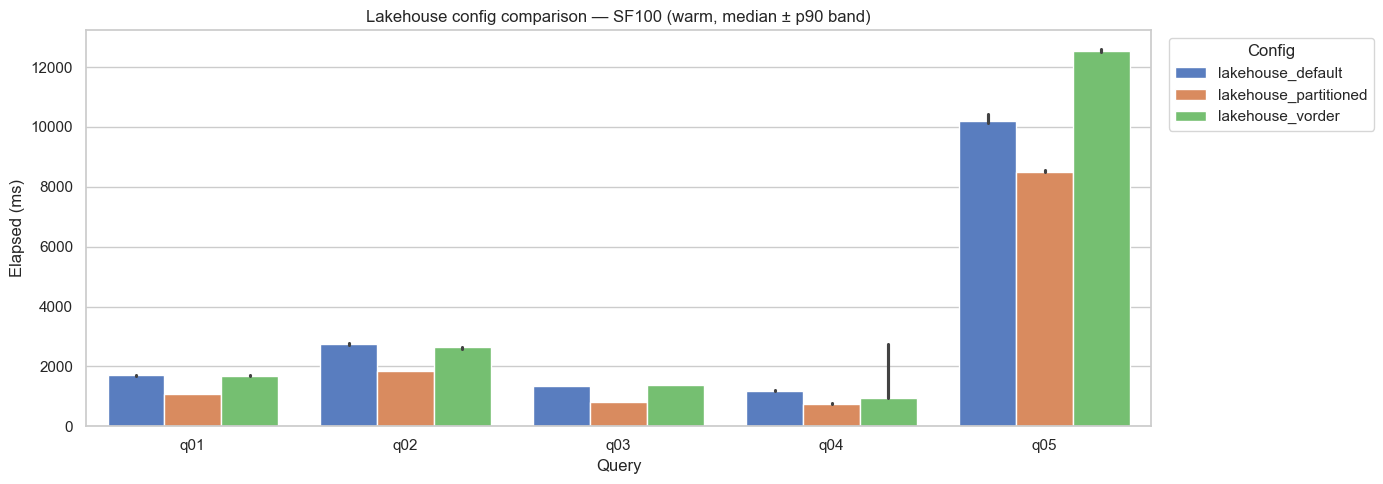

In [14]:
lh_endpoints = [e for e in df_ok['endpoint'].unique()
                if e.startswith('lakehouse_') and not e.endswith('_frag')]
df_lh = df_ok[(df_ok['endpoint'].isin(lh_endpoints)) & (df_ok['cache_mode'] == 'warm')]

for sf in sorted(df_lh['scale_factor'].unique()):
    data = df_lh[df_lh['scale_factor'] == sf]
    fig, ax = plt.subplots(figsize=(14, 5))
    sns.barplot(data=data, x='query_id', y='elapsed_ms', hue='endpoint', ax=ax,
                estimator='median', errorbar=('pi', 90))
    ax.set_title(f'Lakehouse config comparison — {sf} (warm, median ± p90 band)')
    ax.set_xlabel('Query')
    ax.set_ylabel('Elapsed (ms)')
    ax.legend(title='Config', bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

## 6. Distribution — box plots (warm)

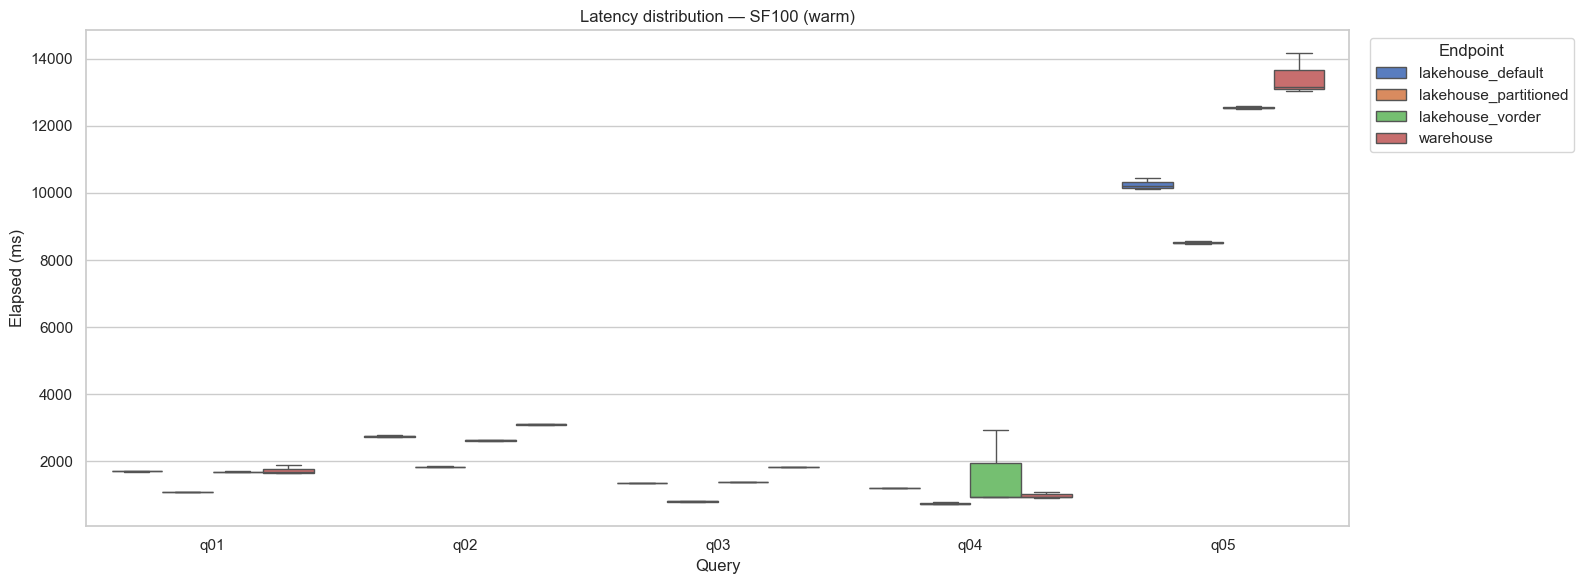

In [15]:
for sf in sorted(df_ok['scale_factor'].unique()):
    _compact = ~df_ok['endpoint'].str.endswith('_frag')
    data = df_ok[(df_ok['scale_factor'] == sf) & (df_ok['cache_mode'] == 'warm') & _compact]
    fig, ax = plt.subplots(figsize=(16, 6))
    sns.boxplot(data=data, x='query_id', y='elapsed_ms', hue='endpoint', ax=ax,
                flierprops=dict(marker='o', markersize=3))
    ax.set_title(f'Latency distribution — {sf} (warm)')
    ax.set_xlabel('Query')
    ax.set_ylabel('Elapsed (ms)')
    ax.legend(title='Endpoint', bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

## 7. Lakehouse vs Warehouse — aggregate comparison

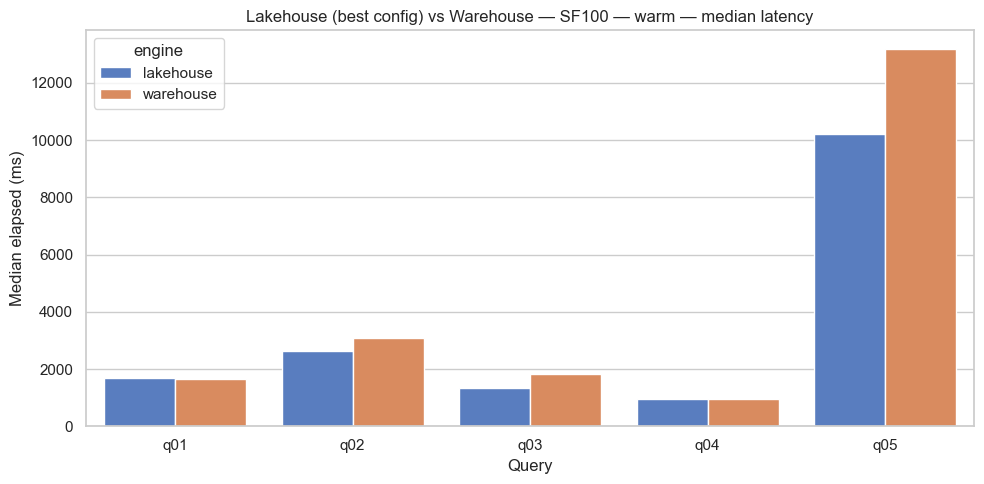

In [16]:
_COMPACT_EPS = ['lakehouse_default', 'lakehouse_partitioned', 'lakehouse_vorder', 'warehouse']
df_compact = df_ok[df_ok['endpoint'].isin(_COMPACT_EPS)].copy()
df_compact['engine'] = df_compact['endpoint'].apply(
    lambda e: 'warehouse' if e == 'warehouse' else 'lakehouse'
)
engine_summary = (
    df_compact[df_compact['cache_mode'] == 'warm']
    .groupby(['scale_factor', 'engine', 'query_id'])['elapsed_ms']
    .median()
    .reset_index()
    .rename(columns={'elapsed_ms': 'median_ms'})
)

for sf in sorted(engine_summary['scale_factor'].unique()):
    data = engine_summary[engine_summary['scale_factor'] == sf]
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=data, x='query_id', y='median_ms', hue='engine', ax=ax)
    ax.set_title(f'Lakehouse (best config) vs Warehouse — {sf} — warm — median latency')
    ax.set_xlabel('Query')
    ax.set_ylabel('Median elapsed (ms)')
    plt.tight_layout()
    plt.show()

## 8. Fragmentation experiment

Analyzes warm-cache results for `warehouse_frag` and `lakehouse_frag` endpoints.
Only shown when result files include fragmented endpoint rows.

**8.1** Individual executions — every repetition, linear scale, independent Y per endpoint.  
**8.2** Average latency — mean of 3 reps, two subplots with independent Y, ×N slowdown vs WH.  
**8.3** Compact vs. fragmented — median comparison per engine.

In [ ]:
# 8.1 Individual executions — grouped bar chart, one facet per endpoint

# Use all available frag warm data.
# run_id is per-execution UUID so we cannot group runs by it;
# instead take median across repeated runs for the same
# (endpoint, query_id, repetition) to deduplicate warehouse_frag
# which has 6 reps (Run A + Run B) vs lakehouse_frag 3 reps (Run A).
_df_frag_all = df_ok[
    df_ok['endpoint'].isin(['warehouse_frag', 'lakehouse_frag']) &
    (df_ok['cache_mode'] == 'warm')
].copy()
if not _df_frag_all.empty:
    _df_frag = (
        _df_frag_all
        .groupby(['endpoint', 'query_id', 'repetition'])['elapsed_ms']
        .median().reset_index()
    )
else:
    _df_frag = pd.DataFrame()

if _df_frag.empty:
    print('No frag results yet — run: py benchmark/runner.py --endpoints warehouse_frag lakehouse_frag --warm-only')
else:
    _df_frag['elapsed_s'] = _df_frag['elapsed_ms'] / 1000
    _queries = sorted(_df_frag['query_id'].unique())
    _reps = sorted(_df_frag['repetition'].unique())
    _rep_colors = {1: '#4c72b0', 2: '#dd8452', 3: '#55a868'}
    _n_reps = len(_reps)
    _width = 0.25
    _x = np.arange(len(_queries))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, endpoint in zip(axes, ['warehouse_frag', 'lakehouse_frag']):
        data = _df_frag[_df_frag['endpoint'] == endpoint]
        for i, rep in enumerate(_reps):
            rd = data[data['repetition'] == rep].set_index('query_id').reindex(_queries)
            vals = rd['elapsed_s'].values
            bars = ax.bar(_x + (i - _n_reps / 2 + 0.5) * _width, vals,
                          width=_width, color=_rep_colors.get(rep, 'grey'),
                          label=f'Rep {rep}', edgecolor='white')
            for bar, v in zip(bars, vals):
                if not np.isnan(v):
                    ax.text(bar.get_x() + bar.get_width() / 2, v,
                            f'{v:.0f}s', ha='center', va='bottom', fontsize=7.5)
        ax.set_title(endpoint.replace('_', ' ').title())
        ax.set_xticks(_x)
        ax.set_xticklabels(_queries)
        ax.set_xlabel('Query')
        ax.set_ylabel('Elapsed (s)')
        ax.legend(title='')
        sns.despine(ax=ax)

    fig.suptitle('Individual executions — frag endpoints — warm — SF100', fontsize=13)
    plt.tight_layout()
    plt.show()

In [ ]:
# 8.2 Average latency — two subplots (linear scale, independent Y) + slowdown factor
if '_df_frag' in dir() and not _df_frag.empty:
    _means = (
        _df_frag
        .groupby(['endpoint', 'query_id'])['elapsed_s']
        .mean().reset_index().rename(columns={'elapsed_s': 'mean_s'})
    )
    _queries_avg = sorted(_means['query_id'].unique())
    _ep_colors = {'warehouse_frag': '#4c72b0', 'lakehouse_frag': '#dd8452'}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, endpoint in zip(axes, ['warehouse_frag', 'lakehouse_frag']):
        ep_data = _means[_means['endpoint'] == endpoint].set_index('query_id')
        vals = [ep_data.loc[q, 'mean_s'] if q in ep_data.index else 0.0 for q in _queries_avg]
        bars = ax.bar(_queries_avg, vals, color=_ep_colors[endpoint], width=0.5)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, v + ax.get_ylim()[1] * 0.01,
                    f'{v:.1f}s', ha='center', va='bottom', fontsize=9)
        ax.set_xlabel('Query')
        ax.set_ylabel('Mean elapsed (s)')
        ax.set_title(endpoint.replace('_', ' ').title())
        sns.despine(ax=ax)

    # Reposition value labels now that ylim is final
    for ax, endpoint in zip(axes, ['warehouse_frag', 'lakehouse_frag']):
        ep_data = _means[_means['endpoint'] == endpoint].set_index('query_id')
        for txt, q in zip(ax.texts, _queries_avg):
            v = ep_data.loc[q, 'mean_s'] if q in ep_data.index else 0.0
            txt.set_y(v + ax.get_ylim()[1] * 0.015)

    # Slowdown annotation on LH subplot
    _wh_m = _means[_means['endpoint'] == 'warehouse_frag'].set_index('query_id')
    _lh_m = _means[_means['endpoint'] == 'lakehouse_frag'].set_index('query_id')
    ax_lh = axes[1]
    for xi, q in enumerate(_queries_avg):
        if q in _wh_m.index and q in _lh_m.index and _wh_m.loc[q, 'mean_s'] > 0:
            factor = _lh_m.loc[q, 'mean_s'] / _wh_m.loc[q, 'mean_s']
            v = _lh_m.loc[q, 'mean_s']
            ax_lh.annotate(f'\u00d7{factor:.0f} vs WH', xy=(xi, v),
                           ha='center', va='bottom', fontsize=8, color='#c44e52',
                           xytext=(0, 22), textcoords='offset points')

    fig.suptitle('Average latency — warehouse_frag vs lakehouse_frag — warm — SF100', fontsize=13)
    plt.tight_layout()
    plt.show()

    # Summary table
    _pivot = _means.pivot(index='query_id', columns='endpoint', values='mean_s').round(1)
    _pivot.columns.name = None
    if 'warehouse_frag' in _pivot.columns and 'lakehouse_frag' in _pivot.columns:
        _pivot['lh_wh_factor_x'] = (_pivot['lakehouse_frag'] / _pivot['warehouse_frag']).round(1)
    print('\nMean latency summary (seconds):')
    print(_pivot.to_string())

In [ ]:
# Map each endpoint to its engine and config type
_CONFIG_MAP = {
    'lakehouse_default':    ('lakehouse', 'compact'),
    'lakehouse_partitioned':('lakehouse', 'compact'),
    'lakehouse_vorder':     ('lakehouse', 'compact'),
    'warehouse':            ('warehouse', 'compact'),
    'lakehouse_frag':       ('lakehouse', 'fragmented'),
    'warehouse_frag':       ('warehouse', 'fragmented'),
}

df_frag_endpoints = df_ok[df_ok['endpoint'].isin(['warehouse_frag', 'lakehouse_frag'])]['endpoint'].unique()
if len(df_frag_endpoints) == 0:
    print('No fragmentation results yet. Run the benchmark with --endpoints warehouse_frag lakehouse_frag first.')
else:
    df_frag = df_ok.copy()
    df_frag[['engine', 'config']] = pd.DataFrame(
        df_frag['endpoint'].map(_CONFIG_MAP).tolist(), index=df_frag.index
    )

    present_engines = df_frag[df_frag['config'] == 'fragmented']['engine'].unique()
    df_frag = df_frag[df_frag['engine'].isin(present_engines)].copy()

    # Best compact config per engine (lowest median across configs)
    compact = (
        df_frag[(df_frag['config'] == 'compact') & (df_frag['cache_mode'] == 'warm')]
        .groupby(['engine', 'endpoint', 'query_id'])['elapsed_ms']
        .median().reset_index()
    )
    best_compact = (
        compact.groupby(['engine', 'query_id'])['elapsed_ms']
        .min().reset_index().rename(columns={'elapsed_ms': 'min_median'})
    )
    compact = compact.merge(best_compact, on=['engine', 'query_id'])
    compact = compact[compact['elapsed_ms'] == compact['min_median']].drop_duplicates(['engine', 'query_id'])
    compact['config'] = 'compact (best)'

    frag_summary = (
        df_frag[(df_frag['config'] == 'fragmented') & (df_frag['cache_mode'] == 'warm')]
        .groupby(['engine', 'query_id'])['elapsed_ms']
        .median().reset_index()
    )
    frag_summary['config'] = 'fragmented'

    combined = pd.concat([
        compact[['engine', 'query_id', 'elapsed_ms', 'config']],
        frag_summary[['engine', 'query_id', 'elapsed_ms', 'config']],
    ], ignore_index=True)

    # Slowdown pivot
    pivot = combined.pivot_table(
        index=['engine', 'query_id'], columns='config', values='elapsed_ms'
    ).reset_index()
    pivot.columns.name = None
    pivot['slowdown_x'] = (pivot['fragmented'] / pivot['compact (best)']).round(1)

    _queries = sorted(combined['query_id'].unique())
    _x = range(len(_queries))
    _palette = {'compact (best)': '#4c72b0', 'fragmented': '#dd8452'}

    for engine in sorted(combined['engine'].unique()):
        d = combined[combined['engine'] == engine]
        p = pivot[pivot['engine'] == engine]

        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        fig.suptitle(
            f'{engine.capitalize()} — compact vs. fragmented — warm — SF100',
            fontsize=13, y=1.01
        )

        # Panel 1: compact only (its own scale)
        dc = d[d['config'] == 'compact (best)'].set_index('query_id').reindex(_queries)
        axes[0].bar(_x, dc['elapsed_ms'].values / 1000, color=_palette['compact (best)'])
        axes[0].set_title('Compact (best config)')
        axes[0].set_xticks(list(_x)); axes[0].set_xticklabels(_queries)
        axes[0].set_xlabel('Query'); axes[0].set_ylabel('Median elapsed (s)')
        for xi, v in zip(_x, dc['elapsed_ms'].values / 1000):
            if not pd.isna(v):
                axes[0].text(xi, v, f'{v:.1f}s', ha='center', va='bottom', fontsize=9)
        sns.despine(ax=axes[0])

        # Panel 2: fragmented only (its own scale)
        df2 = d[d['config'] == 'fragmented'].set_index('query_id').reindex(_queries)
        axes[1].bar(_x, df2['elapsed_ms'].values / 1000, color=_palette['fragmented'])
        axes[1].set_title('Fragmented')
        axes[1].set_xticks(list(_x)); axes[1].set_xticklabels(_queries)
        axes[1].set_xlabel('Query'); axes[1].set_ylabel('Median elapsed (s)')
        for xi, v in zip(_x, df2['elapsed_ms'].values / 1000):
            if not pd.isna(v):
                axes[1].text(xi, v, f'{v:.0f}s', ha='center', va='bottom', fontsize=9)
        sns.despine(ax=axes[1])

        # Panel 3: slowdown factor
        slowdowns = p.set_index('query_id').reindex(_queries)['slowdown_x'].values
        bars = axes[2].bar(_x, slowdowns, color='#c44e52')
        axes[2].axhline(1, color='grey', linewidth=0.8, linestyle='--')
        axes[2].set_title('Slowdown factor (fragmented / compact)')
        axes[2].set_xticks(list(_x)); axes[2].set_xticklabels(_queries)
        axes[2].set_xlabel('Query'); axes[2].set_ylabel('× slower')
        for bar, v in zip(bars, slowdowns):
            if not pd.isna(v):
                axes[2].text(bar.get_x() + bar.get_width() / 2, v,
                             f'{v:.0f}×', ha='center', va='bottom', fontsize=9, fontweight='bold')
        sns.despine(ax=axes[2])

        plt.tight_layout()
        plt.show()

    print()
    print('Fragmentation slowdown factor (fragmented / compact):')
    print(pivot[['engine', 'query_id', 'compact (best)', 'fragmented', 'slowdown_x']].to_string(index=False))
